# Rotating function Testing  

**Purpose**: Code for testing the rotation functions on fake data

**Luke Colosi | lcolosi@ucsd.edu**

Force matplotlib plots to display directly within the output cell of the notebook: 

In [1]:
%matplotlib inline


Import python libraries


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from pyproj import Geod
from scipy.interpolate import griddata

# Set path to access python functions
sys.path.append('/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/AirSeaCoupling/tools/')

#--- Luke's Python Functions ---# 
from autocorr import compute_decor_scale, compute_autocorr

In [3]:
def largest_centered_square_halfwidth(Xr, Yr, shrink_eps=1e-6, iters=32):

    """
    Compute the half-width (crop_half) of the largest axis-aligned square,
    centered at (0,0), that fits entirely within the convex hull of the
    rotated grid points (Xr, Yr).

    Parameters
    ----------
    Xr, Yr : 2D arrays
        Rotated x and y coordinates (km).
    shrink_eps : float, optional
        Small fractional shrink factor to avoid floating-point boundary issues.
        The final half-width is reduced by (1 - shrink_eps).
    iters : int, optional
        Number of bisection iterations (more = finer precision).

    Returns
    -------
    crop_half : float
        Half-width (km) of the largest centered square that fits within
        the convex hull of (Xr, Yr).
    """

    # Import libraries
    from scipy.spatial import ConvexHull
    from matplotlib.path import Path
    import numpy as np

    # --- Step 1: Flatten all rotated coordinates into N×2 array of points ---
    pts = np.column_stack((Xr.ravel(), Yr.ravel()))

    # --- Step 2: Compute convex hull enclosing all rotated grid points ---
    # The convex hull is the smallest polygon containing all data points.
    hull = ConvexHull(pts)

    # Extract the ordered vertices of that polygon
    poly = pts[hull.vertices]

    # --- Step 3: Create a Path object for efficient point-in-polygon testing ---
    path = Path(poly)

    # --- Step 4: Define upper and lower bounds for half-width search ---
    # Start with the half-length of the smallest bounding-box side as the max possible.
    x_min, x_max = Xr.min(), Xr.max()
    y_min, y_max = Yr.min(), Yr.max()
    hi = min((x_max - x_min), (y_max - y_min)) * 0.5
    lo = 0.0  # lower bound starts at zero

    # --- Step 5: Use bisection search to find the largest inscribed square ---
    # The algorithm repeatedly tests if a square of half-width h is fully inside the hull.
    for _ in range(iters):

        # Test the midpoint of the current [lo, hi] range
        h = 0.5 * (lo + hi)

        # Define the four corners of a centered square with half-width h
        corners = np.array([[ h,  h],
                            [ h, -h],
                            [-h,  h],
                            [-h, -h]])

        # Check whether all four corners lie inside the convex hull polygon
        inside = path.contains_points(corners).all()

        # If all corners are inside, we can expand the square (move lower bound up)
        if inside:
            lo = h
        # Otherwise, shrink the candidate square (move upper bound down)
        else:
            hi = h

    # --- Step 6: Apply a tiny shrink factor to guarantee it's strictly inside ---
    crop_half = lo * (1.0 - shrink_eps)

    return crop_half


def rotate_field(data, lon, lat, theta_deg, dx_r = 1.5, dy_r = 1.5):
    """
    Rotate a 2D field clockwise by a given angle and crop to a square region.

    Parameters
    ----------
    data : 2D array (lat x lon)
        Input field to rotate.
    lon, lat : 1D arrays
        Longitude and latitude coordinates of the field.
    theta_deg : float
        Clockwise rotation angle in degrees.
    dx_r, dy_r : float
        Rotated coordinates' resolution in kilometers 

    Returns
    -------
    data_rot_crop : 2D array
        Rotated and cropped field (on a regular square grid in km).
    X_new, Y_new : 2D arrays
        Corresponding km-coordinate grids after rotation.
    """

    # Import libraries
    import numpy as np
    from pyproj import Geod
    from scipy.interpolate import griddata

    ###################################################
    # STEP 1: Convert lat/lon to distances (km) relative to grid center 
    ###################################################
    
    # Set geoid 
    geod = Geod(ellps="WGS84")

    # Set center longitude and latitude (origin of the transformed coordinate system) and the length of the coordinate vectors
    lon0, lat0 = np.mean(lon), np.mean(lat)
    nx, ny = len(lon), len(lat)

    # Initialize northing and easting coordinates
    x_cor = np.zeros(nx)
    y_cor = np.zeros(ny)

    # Loop through longtiude
    for i in range(nx):

        # Compute the distance from the origin 
        _, _, dist = geod.inv(lon0, lat0, lon[i], lat0)

        # Convert to kilometers and set the sign of x-coordinate vector (West of origin = negative)
        x_cor[i] = np.sign(lon[i] - lon0) * dist / 1000  # km

    # Loop through Latitude
    for j in range(ny):

        # Compute the distance from the origin
        _, _, dist = geod.inv(lon0, lat0, lon0, lat[j])

        # Convert to kilometers and set the sign of y-coordinate vector (SOuth of origin = negative)
        y_cor[j] = np.sign(lat[j] - lat0) * dist / 1000  # km

    # Create a mesh grid 
    X, Y = np.meshgrid(x_cor, y_cor)

    ###################################################
    # STEP 2: Rotate coordinate system clockwise 
    ###################################################
    
    # Convert the angle to radians
    theta = np.deg2rad(theta_deg)

    # Rotate coordinate vectors
    Xr =  X * np.cos(theta) + Y * np.sin(theta)
    Yr = -X * np.sin(theta) + Y * np.cos(theta)

    # Flatten arrays
    Xr_flat = Xr.flatten()
    Yr_flat = Yr.flatten()
    data_flat = data.flatten()

    ###################################################
    # STEP 3: Crop data within largest inscribed square 
    ###################################################

    # Set half-width of the biggest square you can draw inside the rotated data region
    crop_half = largest_centered_square_halfwidth(Xr, Yr)

    # Obtain indices of cropped region
    idx_x = (Xr_flat >= -crop_half) & (Xr_flat <= crop_half)
    idx_y = (Yr_flat >= -crop_half) & (Yr_flat <= crop_half)
    idx = np.logical_and(idx_x, idx_y)

    # Apply cropping mask
    xr_crop, yr_crop, data_crop = Xr_flat[idx], Yr_flat[idx], data_flat[idx]

    ###################################################
    # Step 4: Interpolate cropped region onto a regular grid
    ###################################################
    
    # Set your grid extent
    xr_min, xr_max = xr_crop.min(), xr_crop.max()
    yr_min, yr_max = yr_crop.min(), yr_crop.max()

    # Define new grid 
    xr_grid = np.arange(xr_min, xr_max + dx_r, dx_r) 
    yr_grid = np.arange(yr_min, yr_max + dy_r, dy_r)

    # Set the meshgrid
    XG, YG = np.meshgrid(xr_grid, yr_grid)  # shape (Ny, Nx)

    # Flatten coordinates
    points = np.stack([xr_crop, yr_crop], axis=-1)  # shape (N, 2)

    # Interpolate SST onto grid
    data_grid = griddata(
        points, data_crop, (XG, YG),
        method='linear'  # or 'cubic', or 'nearest'
    )

    ###################################################
    # STEP 5: Trim NaN values at the edges of the interpolated grid
    ###################################################
    
    # Define a mask where NaNs = 0, Valid points = 1
    mask = ~np.isnan(data_grid)

    # Find the rows and columns with at least one valid point
    row_inds = np.where(mask.any(axis=1))[0]
    col_inds = np.where(mask.any(axis=0))[0]

    # Trim the coordinates and data 
    data_trim = data_grid[row_inds[0]:row_inds[-1]+1, col_inds[0]:col_inds[-1]+1]
    XG_trim = XG[row_inds[0]:row_inds[-1]+1, col_inds[0]:col_inds[-1]+1]
    YG_trim = YG[row_inds[0]:row_inds[-1]+1, col_inds[0]:col_inds[-1]+1]

    # Define another mask with trimmed array  
    mask = ~np.isnan(data_trim)

    # Compute the fraction of valid points in across rows and columns
    row_valid_frac = mask.mean(axis=1)
    col_valid_frac = mask.mean(axis=0)

    # Find rows and columns that have at least 95% filled with valid points
    valid_rows = np.where(row_valid_frac > 0.95)[0]  
    valid_cols = np.where(col_valid_frac > 0.95)[0]

    # Trim array 
    if len(valid_rows) > 0 and len(valid_cols) > 0:
        row_min, row_max = valid_rows[0], valid_rows[-1]
        col_min, col_max = valid_cols[0], valid_cols[-1]

        data_n = data_trim[row_min:row_max+1, col_min:col_max+1]
        X_n = XG_trim[row_min:row_max+1, col_min:col_max+1]
        Y_n = YG_trim[row_min:row_max+1, col_min:col_max+1]
    else:
        raise ValueError("No fully valid (non-NaN) region found in data.")
    
    # Reset the origin 
    X_n = X_n - np.min(X_n)
    Y_n = Y_n - np.min(Y_n)

    return data_n, X_n, Y_n

Create fake data

In [4]:
# --- Create fake lat/lon data --- #
lat = np.linspace(34, 35, 19)       
lon = np.linspace(-122, -121, 23)    
Lon, Lat = np.meshgrid(lon, lat)

# --- Create fake field: a 2D Gaussian blob + gradient --- #
data = np.exp(-((Lon + 121.5)**2 + (Lat - 34.5)**2) / 0.01)
data += 0.5 * Lon  

Step 1: Convert lat/lon to distances (km) relative to grid center

In [5]:
# Set geoid 
geod = Geod(ellps="WGS84")

# Set center longitude and latitude (origin of the transformed coordinate system) and the length of the coordinate vectors
lon0, lat0 = np.mean(lon), np.mean(lat)
nx, ny = len(lon), len(lat)

# Initialize northing and easting coordinates
x_cor = np.zeros(nx)
y_cor = np.zeros(ny)

# Loop through longtiude
for i in range(nx):

    # Compute the distance from the origin 
    _, _, dist = geod.inv(lon0, lat0, lon[i], lat0)

    # Convert to kilometers and set the sign of x-coordinate vector (West of origin = negative)
    x_cor[i] = np.sign(lon[i] - lon0) * dist / 1000  # km

# Loop through Latitude
for j in range(ny):

    # Compute the distance from the origin
    _, _, dist = geod.inv(lon0, lat0, lon0, lat[j])

    # Convert to kilometers and set the sign of y-coordinate vector (SOuth of origin = negative)
    y_cor[j] = np.sign(lat[j] - lat0) * dist / 1000  # km

# Create a mesh grid 
X, Y = np.meshgrid(x_cor, y_cor)

Rotate the easting and northing coordinates

In [6]:
# Set parameters
theta_deg = 30

# Convert the angle to radians
theta = np.deg2rad(theta_deg)

# Rotate coordinate vectors
Xr =  X * np.cos(theta) + Y * np.sin(theta)
Yr = -X * np.sin(theta) + Y * np.cos(theta)

# Flatten arrays
Xr_flat = Xr.flatten()
Yr_flat = Yr.flatten()
data_flat = data.flatten()

Plot the coordinate transformed data in the new coordinate system 

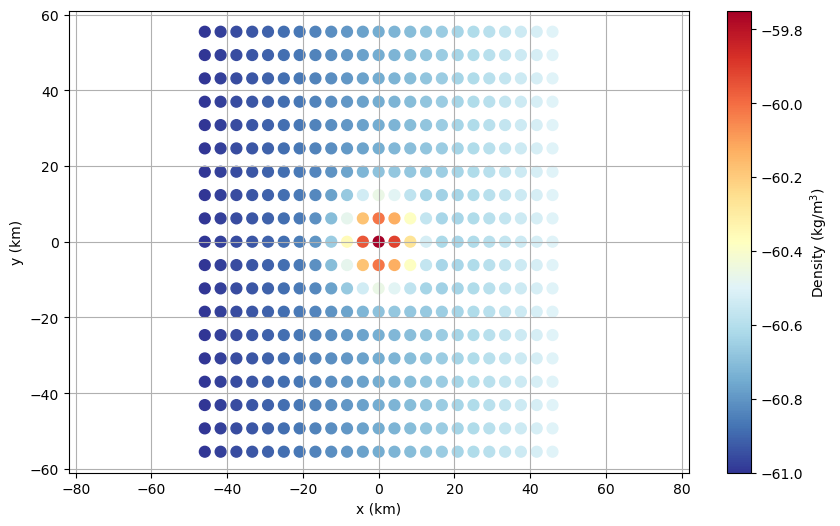

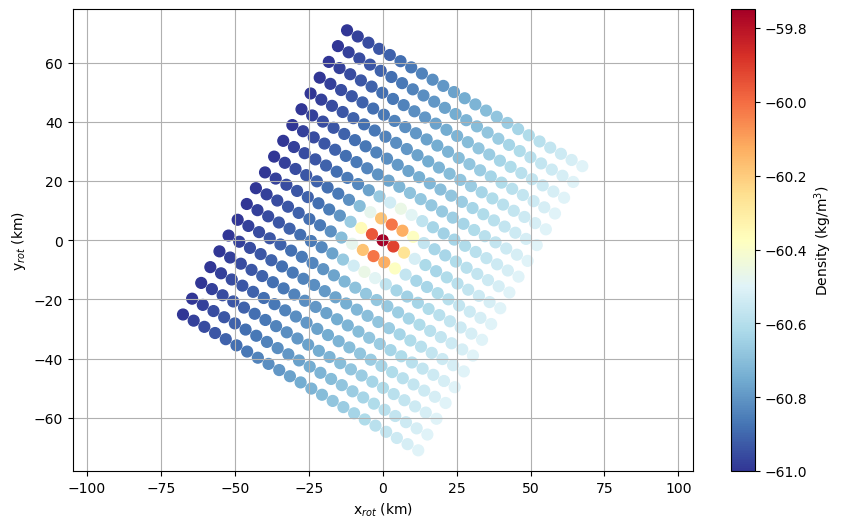

In [7]:
plt.figure(figsize=(10, 6))
plt.scatter(X.flatten(), Y.flatten(), c=data_flat, cmap='RdYlBu_r', s=60)
plt.colorbar(label=r'Density (kg/m$^3$)')
plt.xlabel(r'x (km)')
plt.ylabel(r'y (km)')
plt.axis('equal')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(Xr_flat, Yr_flat, c=data_flat, cmap='RdYlBu_r', s=60)
plt.colorbar(label=r'Density (kg/m$^3$)')
plt.xlabel(r'x$_{rot}$ (km)')
plt.ylabel(r'y$_{rot}$ (km)')
plt.axis('equal')
plt.grid(True)
plt.show()

Determine crop limits for largest inscribed square

In [8]:
crop_half = largest_centered_square_halfwidth(Xr, Yr)
print(crop_half)

33.61569842988407


Crop data within largest inscribed square

In [9]:
# Crop data from just within a domain in the (s,n) space that has not land and constant boundaries
idx_x = (Xr_flat >= -crop_half) & (Xr_flat <= crop_half)
idx_y = (Yr_flat >= -crop_half) & (Yr_flat <= crop_half)
idx = np.logical_and(idx_x, idx_y)
xr_crop, yr_crop, data_crop = Xr_flat[idx], Yr_flat[idx], data_flat[idx]

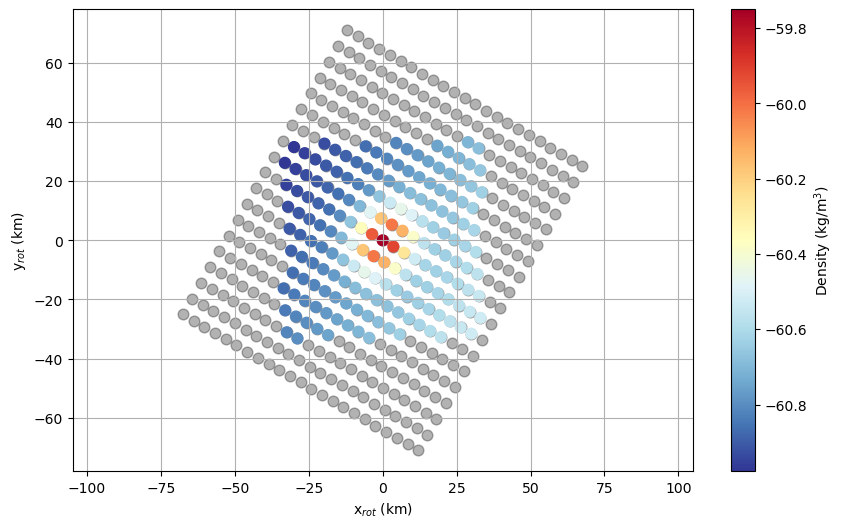

In [10]:
plt.figure(figsize=(10, 6))
plt.scatter(Xr_flat, Yr_flat, color='k', s=60, alpha=0.3)
plt.scatter(xr_crop, yr_crop, c=data_crop, cmap='RdYlBu_r', s=60)
plt.colorbar(label=r'Density (kg/m$^3$)')
plt.xlabel(r'x$_{rot}$ (km)')
plt.ylabel(r'y$_{rot}$ (km)')
plt.axis('equal')
plt.grid(True)
plt.show()

Now let's put the data back on a regular grid in (x_r,y_r) space

In [11]:
import numpy as np

def trim_until_no_edge_nans(Z, X=None, Y=None):
    """
    Iteratively remove outer rows/cols that contain ANY NaNs until
    the outermost perimeter is all valid.

    Parameters
    ----------
    Z : 2D array
        Data array with NaNs.
    X, Y : 2D arrays, optional
        Coordinate arrays aligned with Z.

    Returns
    -------
    Zt, Xt, Yt : 2D arrays
        Trimmed arrays. X/Y returned only if provided.
    """
    r0, r1 = 0, Z.shape[0] - 1
    c0, c1 = 0, Z.shape[1] - 1

    def edge_has_nan(A, r0, r1, c0, c1):
        top    = np.isnan(A[r0, c0:c1+1]).any()
        bottom = np.isnan(A[r1, c0:c1+1]).any()
        left   = np.isnan(A[r0:r1+1, c0]).any()
        right  = np.isnan(A[r0:r1+1, c1]).any()
        return top, bottom, left, right

    # Trim until no NaNs on the outer border or array collapses
    while r0 <= r1 and c0 <= c1:
        top, bottom, left, right = edge_has_nan(Z, r0, r1, c0, c1)
        if not (top or bottom or left or right):
            break  # border is clean

        if top and r0 < r1:    r0 += 1
        if bottom and r1 > r0: r1 -= 1
        if left and c0 < c1:   c0 += 1
        if right and c1 > c0:  c1 -= 1

        # stop if degenerate
        if r0 > r1 or c0 > c1:
            raise ValueError("No border without NaNs exists.")

    Zt = Z[r0:r1+1, c0:c1+1]
    if X is None or Y is None:
        return Zt
    Xt = X[r0:r1+1, c0:c1+1]
    Yt = Y[r0:r1+1, c0:c1+1]
    return Zt, Xt, Yt


Trimmed shape: (41, 41)
Remaining NaNs: 0


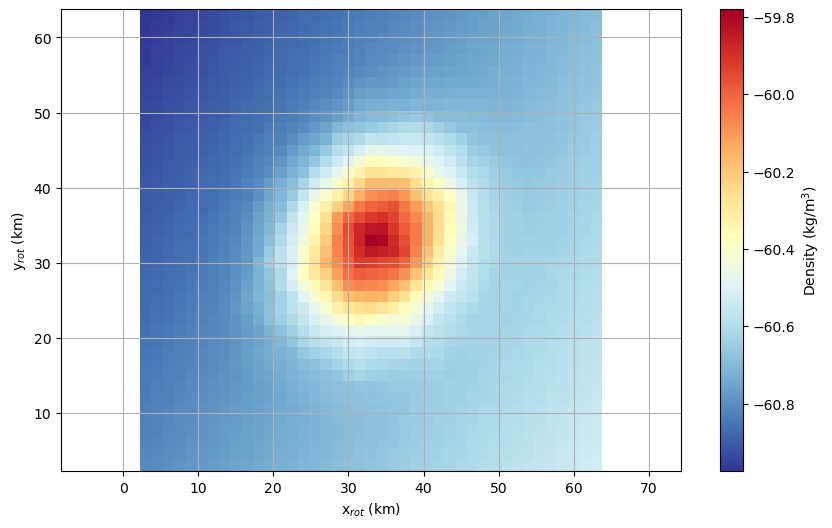

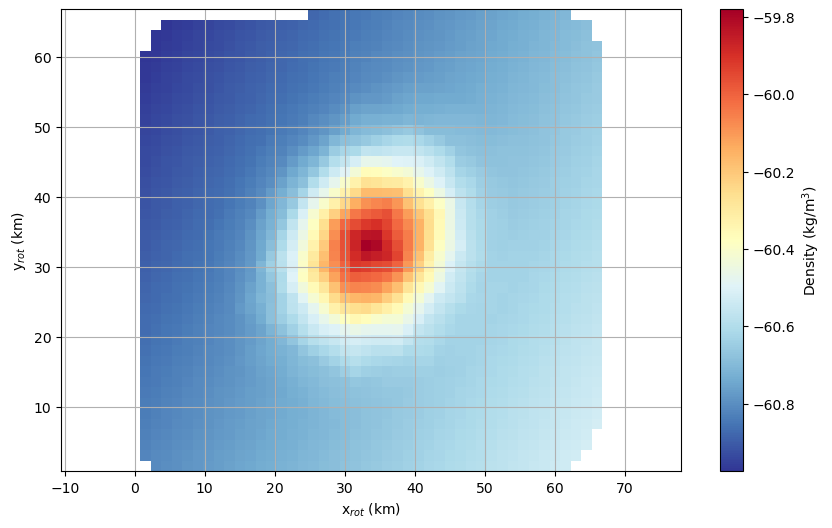

In [12]:
# Set your grid extent
xr_min, xr_max = xr_crop.min(), xr_crop.max()
yr_min, yr_max = yr_crop.min(), yr_crop.max()

# Choose regular grid resolution
dxr = 1.5  # Units: km (or adjust for your resolution)
dyr = 1.5

# Define new grid 
xr_grid = np.arange(xr_min, xr_max + dxr, dxr) 
yr_grid = np.arange(yr_min, yr_max + dyr, dyr)

# Reset the origin of xr_grid and yr_grid
xr_crop_n = xr_crop - xr_min
xr_grid_n = xr_grid - xr_min

yr_crop_n = yr_crop - yr_min
yr_grid_n = yr_grid - yr_min

# Set the meshgrid
XG, YG = np.meshgrid(xr_grid_n, yr_grid_n)  # shape (Ny, Nx)

# Flatten coordinates
points = np.stack([xr_crop_n, yr_crop_n], axis=-1)  # shape (N, 2)

# Interpolate SST onto grid
data_grid = griddata(
    points, data_crop, (XG, YG),
    method='linear'  # or 'cubic', or 'nearest'
)

# Set NaNs to masked values
mask = ~np.isnan(data_grid)

# Find the rows and columns with at least one valid point
row_inds = np.where(mask.any(axis=1))[0]
col_inds = np.where(mask.any(axis=0))[0]

# Trim the coordinates and data 
data_trim = data_grid[row_inds[0]:row_inds[-1]+1, col_inds[0]:col_inds[-1]+1]
XG_trim = XG[row_inds[0]:row_inds[-1]+1, col_inds[0]:col_inds[-1]+1]
YG_trim = YG[row_inds[0]:row_inds[-1]+1, col_inds[0]:col_inds[-1]+1]

# Set mask again 
mask = ~np.isnan(data_trim)

row_valid_frac = mask.mean(axis=1)
col_valid_frac = mask.mean(axis=0)

valid_rows = np.where(row_valid_frac > 0.95)[0]  # at least 95% valid
valid_cols = np.where(col_valid_frac > 0.95)[0]

# Now trim to the bounding box of fully valid region
if len(valid_rows) > 0 and len(valid_cols) > 0:
    row_min, row_max = valid_rows[0], valid_rows[-1]
    col_min, col_max = valid_cols[0], valid_cols[-1]

    data_n = data_trim[row_min:row_max+1, col_min:col_max+1]
    X_n = XG_trim[row_min:row_max+1, col_min:col_max+1]
    Y_n = YG_trim[row_min:row_max+1, col_min:col_max+1]
else:
    raise ValueError("No fully valid (non-NaN) region found in data.")

print(f"Trimmed shape: {data_n.shape}")
print("Remaining NaNs:", np.isnan(data_n).sum())

# Plot semi-final product
plt.figure(figsize=(10, 6))
plt.pcolormesh(X_n, Y_n, data_n, cmap='RdYlBu_r', shading='Auto')
plt.colorbar(label=r'Density (kg/m$^3$)')
plt.xlabel(r'x$_{rot}$ (km)')
plt.ylabel(r'y$_{rot}$ (km)')
plt.axis('equal')
plt.grid(True)
plt.show()

# Plot final product
plt.figure(figsize=(10, 6))
plt.pcolormesh(XG_trim, YG_trim, data_trim, cmap='RdYlBu_r', shading='Auto')
plt.colorbar(label=r'Density (kg/m$^3$)')
plt.xlabel(r'x$_{rot}$ (km)')
plt.ylabel(r'y$_{rot}$ (km)')
plt.axis('equal')
plt.grid(True)
plt.show()

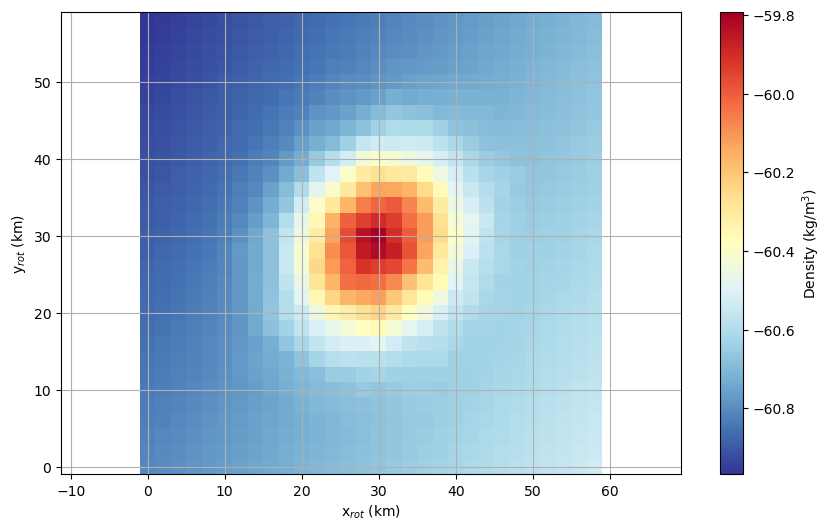

In [19]:
data_n, X_n, Y_n = rotate_field(data, lon, lat, 30, dx_r = 2, dy_r = 2)

# Plot final product
plt.figure(figsize=(10, 6))
plt.pcolormesh(X_n, Y_n, data_n, cmap='RdYlBu_r', shading='Auto')
plt.colorbar(label=r'Density (kg/m$^3$)')
plt.xlabel(r'x$_{rot}$ (km)')
plt.ylabel(r'y$_{rot}$ (km)')
plt.axis('equal')
plt.grid(True)
plt.show()

In [16]:
Y_n[:,0]

array([ 0.,  2.,  4.,  6.,  8., 10., 12., 14., 16., 18., 20., 22., 24.,
       26., 28., 30., 32., 34., 36., 38., 40., 42., 44., 46., 48., 50.,
       52., 54., 56., 58., 60., 62., 64., 66., 68., 70., 72., 74., 76.,
       78., 80., 82.])

In [17]:
X_n[0,:]

array([ 0.,  2.,  4.,  6.,  8., 10., 12., 14., 16., 18., 20., 22., 24.,
       26., 28., 30., 32., 34., 36., 38., 40., 42., 44., 46., 48., 50.,
       52., 54., 56., 58., 60., 62., 64., 66., 68., 70., 72., 74., 76.,
       78., 80., 82., 84., 86.])

In [1]:
import numpy as np
from pyproj import Geod

def lonlat_to_xy_km(lon, lat, ellps="WGS84"):
    """
    Convert longitude and latitude arrays into Cartesian distances (km)
    relative to the grid center using a geodesic projection.

    Parameters
    ----------
    lon : 1D array
        Longitudes of grid points (degrees).
    lat : 1D array
        Latitudes of grid points (degrees).
    ellps : str, optional
        Ellipsoid model to use for geodesic calculations (default: 'WGS84').

    Returns
    -------
    X, Y : 2D arrays
        Meshgrid arrays of Cartesian coordinates (km) relative to grid center.
        X increases eastward, Y increases northward.
    x_cor, y_cor : 1D arrays
        1D coordinate vectors in km corresponding to lon and lat inputs.

    Notes
    -----
    - The coordinate origin (0,0) is set at the mean longitude and latitude.
    - Distances are computed along great circles (geodesics).
    - Output units are kilometers.
    """
    # Initialize geodesic object
    geod = Geod(ellps=ellps)

    # Define grid center
    lon0, lat0 = np.mean(lon), np.mean(lat)
    nx, ny = len(lon), len(lat)

    # Initialize coordinate arrays
    x_cor = np.zeros(nx)
    y_cor = np.zeros(ny)

    # --- Compute easting distances (x) ---
    for i in range(nx):
        _, _, dist = geod.inv(lon0, lat0, lon[i], lat0)
        x_cor[i] = np.sign(lon[i] - lon0) * dist / 1000  # km

    # --- Compute northing distances (y) ---
    for j in range(ny):
        _, _, dist = geod.inv(lon0, lat0, lon0, lat[j])
        y_cor[j] = np.sign(lat[j] - lat0) * dist / 1000  # km

    # --- Create meshgrid ---
    X, Y = np.meshgrid(x_cor, y_cor)

    return X, Y, x_cor, y_cor


# Example longitude/latitude vectors
lon = np.linspace(-121, -120, 51)
lat = np.linspace(33, 34, 51)

# Convert to Cartesian coordinates
X, Y, x_cor, y_cor = lonlat_to_xy_km(lon, lat)

print(f"x range: {x_cor[0]:.2f} to {x_cor[-1]:.2f} km")
print(f"y range: {y_cor[0]:.2f} to {y_cor[-1]:.2f} km")

x range: -46.46 to 46.46 km
y range: -55.45 to 55.46 km


In [2]:
def lonlat_to_xy_km(lon, lat, lon0=None, lat0=None, ellps="WGS84", return_vectors=False):
    """
    Convert longitude and latitude coordinates to Cartesian distances (km)
    relative to a specified or automatic origin.

    Parameters
    ----------
    lon : array_like
        Longitudes of data points (degrees). Can be 1D or 2D.
    lat : array_like
        Latitudes of data points (degrees). Must have same shape as lon.
    lon0 : float, optional
        Longitude of origin (degrees). If None, uses mean(lon).
    lat0 : float, optional
        Latitude of origin (degrees). If None, uses mean(lat).
    ellps : str, default='WGS84'
        Ellipsoid model used for great-circle distance calculations.
        Common options: 'WGS84', 'sphere', 'GRS80', etc.
    return_vectors : bool, default=False
        If True and input is 1D, also returns 1D coordinate vectors (x_cor, y_cor).

    Returns
    -------
    X, Y : ndarray
        Cartesian coordinates (km) relative to origin.
        X increases eastward, Y increases northward.
    lon0, lat0 : float
        Longitude and latitude of the chosen origin (degrees).
    x_cor, y_cor : 1D arrays, optional
        Only returned if `return_vectors=True` and input is 1D.

    Notes
    -----
    - Distances are computed geodesically using pyproj.Geod.
    - The coordinate origin (0, 0) is located at (lon0, lat0).
    - Sign convention:
        East of origin → +X
        North of origin → +Y
    - If `lon` and `lat` are 1D, outputs are 2D meshgrids created from them.
    """

    # Import libraries
    import numpy as np
    from pyproj import Geod

    # ---------------------------------------------------
    # 1. Initialize geodesic and input arrays
    # ---------------------------------------------------
    geod = Geod(ellps=ellps)
    lon = np.asarray(lon)
    lat = np.asarray(lat)

    # Validate inputs
    if lon.shape != lat.shape and not (lon.ndim == 1 and lat.ndim == 1):
        raise ValueError("lon and lat must be either 1D arrays of same length or 2D arrays of same shape.")

    # ---------------------------------------------------
    # 2. Determine the origin
    # ---------------------------------------------------
    if lon0 is None:
        lon0 = np.nanmean(lon)
    if lat0 is None:
        lat0 = np.nanmean(lat)

    # ---------------------------------------------------
    # 3. Handle 1D coordinate case
    # ---------------------------------------------------
    if lon.ndim == 1 and lat.ndim == 1:
        nx, ny = len(lon), len(lat)

        # Initialize coordinate vectors
        x_cor = np.zeros(nx)
        y_cor = np.zeros(ny)

        # --- Compute easting distances (longitude direction) ---
        for i in range(nx):
            # Compute geodesic distance from origin to (lon[i], lat0)
            _, _, dist = geod.inv(lon0, lat0, lon[i], lat0)
            # Convert to km and apply sign (west = negative)
            x_cor[i] = np.sign(lon[i] - lon0) * dist / 1000

        # --- Compute northing distances (latitude direction) ---
        for j in range(ny):
            # Compute geodesic distance from origin to (lon0, lat[j])
            _, _, dist = geod.inv(lon0, lat0, lon0, lat[j])
            # Convert to km and apply sign (south = negative)
            y_cor[j] = np.sign(lat[j] - lat0) * dist / 1000

        # --- Create 2D meshgrids ---
        X, Y = np.meshgrid(x_cor, y_cor)

        # Optionally return 1D vectors
        if return_vectors:
            return X, Y, lon0, lat0, x_cor, y_cor
        else:
            return X, Y, lon0, lat0

    # ---------------------------------------------------
    # 4. Handle 2D coordinate case (curvilinear grid)
    # ---------------------------------------------------
    elif lon.ndim == 2 and lat.ndim == 2:
        # Initialize output arrays
        X = np.zeros_like(lon, dtype=float)
        Y = np.zeros_like(lat, dtype=float)

        # Compute X and Y distances for each point
        for j in range(lat.shape[0]):
            for i in range(lon.shape[1]):
                # East-west distance (km)
                _, _, dist_x = geod.inv(lon0, lat0, lon[j, i], lat0)
                X[j, i] = np.sign(lon[j, i] - lon0) * dist_x / 1000
                # North-south distance (km)
                _, _, dist_y = geod.inv(lon0, lat0, lon0, lat[j, i])
                Y[j, i] = np.sign(lat[j, i] - lat0) * dist_y / 1000

        # Return 2D coordinate fields and origin
        return X, Y, lon0, lat0

lon = np.linspace(-121, -120, 51)
lat = np.linspace(33, 34, 51)

X, Y, lon0, lat0, x_cor, y_cor = lonlat_to_xy_km(lon, lat, return_vectors=True)

print(f"Origin: ({lon0:.3f}°, {lat0:.3f}°)")
print(f"x range: {x_cor[0]:.2f} to {x_cor[-1]:.2f} km")
print(f"y range: {y_cor[0]:.2f} to {y_cor[-1]:.2f} km")


Origin: (-120.500°, 33.500°)
x range: -46.46 to 46.46 km
y range: -55.45 to 55.46 km
